# LArEventDisplay FSD Example -- COPY ME

#### LArEventDisplay is the FSD event display class defined in larFSD_evd.py which uses datasets from `proto_nd_flow`-ed files. For scanning through events, please make a copy of this notebook to use and update locally. Please DO NOT commit changes to this example notebook.

In [1]:
import sys
# Change below to match your path to ndlar_flow/event_display/LAr_evd
sys.path.append('/your/path/to/ndlar_flow/event_display/LAr_evd/')
from larFSD_evd import *
plt.ion()

Hello


#### Inputs to LArEventDisplay:

- `filedir`           (str): path to input file
- `filename`          (str): name of file; must be flow file run through `proto_nd_flow`
- `runsdb`            (str): string giving sqlite3 path to relevant runs database location. The default is 'sqlite:////global/cfs/cdirs/dune/www/data/2x2/DB/RunsDB/releases/mx2x2runs_v0.1_alpha3.sqlite', which reflects the current location of the runs database on NERSC for high purity data runs in July 2024.
- `nhits_min`         (int): minimum number of hits (threshold) in event selection (default: 1)
- `nhits_max`         (int): maximum number of hits allowed in event selection (default: 1e10)
- `ntrigs`            (int): minimum number of external triggers required in event selection (default=0)
- `show_light`        (bool): show light information in display (default: True)
- `light_event_only`  (bool): only the events containing light information are displayed (default: False)
- `show_colorbars`    (bool): display the color bars (default: True)
- `charge_threshold`  (float): threshold for charge hits to be shown (default: None)
- `light_threshold`   (float): threshold for light to be shown (default: 1000 ADC counts)
- `beam_only`         (bool): only show beam events (default: False)
- `hist_projection`   (bool): if True, hits are binned in a 2D histogram for the 2D charge hit projections. Bins with 0 charge are not displayed. If False, hits are plotted as scatter points for the 2D charge hit projections. For the histograms, sizes are the same for beam, drift, and vertical axes even though drift coordinate resolution may be finer than the resolution in beam/vertical (pixel) dimensions. While binning covers the spaces between modules, it does not cover space external to the modules (only expected for unphysical detector responses or in the case of an event building bug.) (default: True)
- `show_fig_wfms`     (bool):  show a second figure with the light waveforms and SiPM coordinates (default: False)
- `ouput_path`        (str):  Path where to save the figures, if None: save in ./FSD_eventDisplay/ (default: None)

Please note that:
    - whether `hist_projection` is True or False, all histogram bins and/or points in all plots (2D and 3D) are slightly larger than pixel pitch-sized by default. This is because the interactive viewer is unable to clearly resolve points/bins reflecting the pixel pitch.
    - The cathode is displayed ticked than its true size for illustrative purpose.



In [2]:
# This set of inputs allows you to look at a data file from ...
dFSD = '/global/cfs/cdirs/dune/users/ajwhite/FSD_Data/Geometry_Check/2024_11_08/'
fFSD = 'packet-0020114-2024_11_08_22_54_17_CET.CL_MATCHED.G_v6.hdf5'

#### Running the following cell will show the event display and a user input box. User input options are:

 - `Enter`           : proceed to the next available event
 - `n`+`Enter`       : proceed to the Event `n`
 - `l`+`Enter`       : save current event display to a PDF with points scaled to pixel pitch
 - `s`+`Enter`       : save current event display as .png
 - `q`+`Enter`       : quit the event display

Processing file /Users/nsallin/develop/data/FSD/CLMatched/packet-0020114-2024_11_08_22_54_17_CET.CL_MATCHED.G_v6.hdf5
The output path is set to /Users/nsallin/develop/ndlar_flow/event_display/LAr_evd/FSD_eventDisplay/
Number of events in the selection: 27


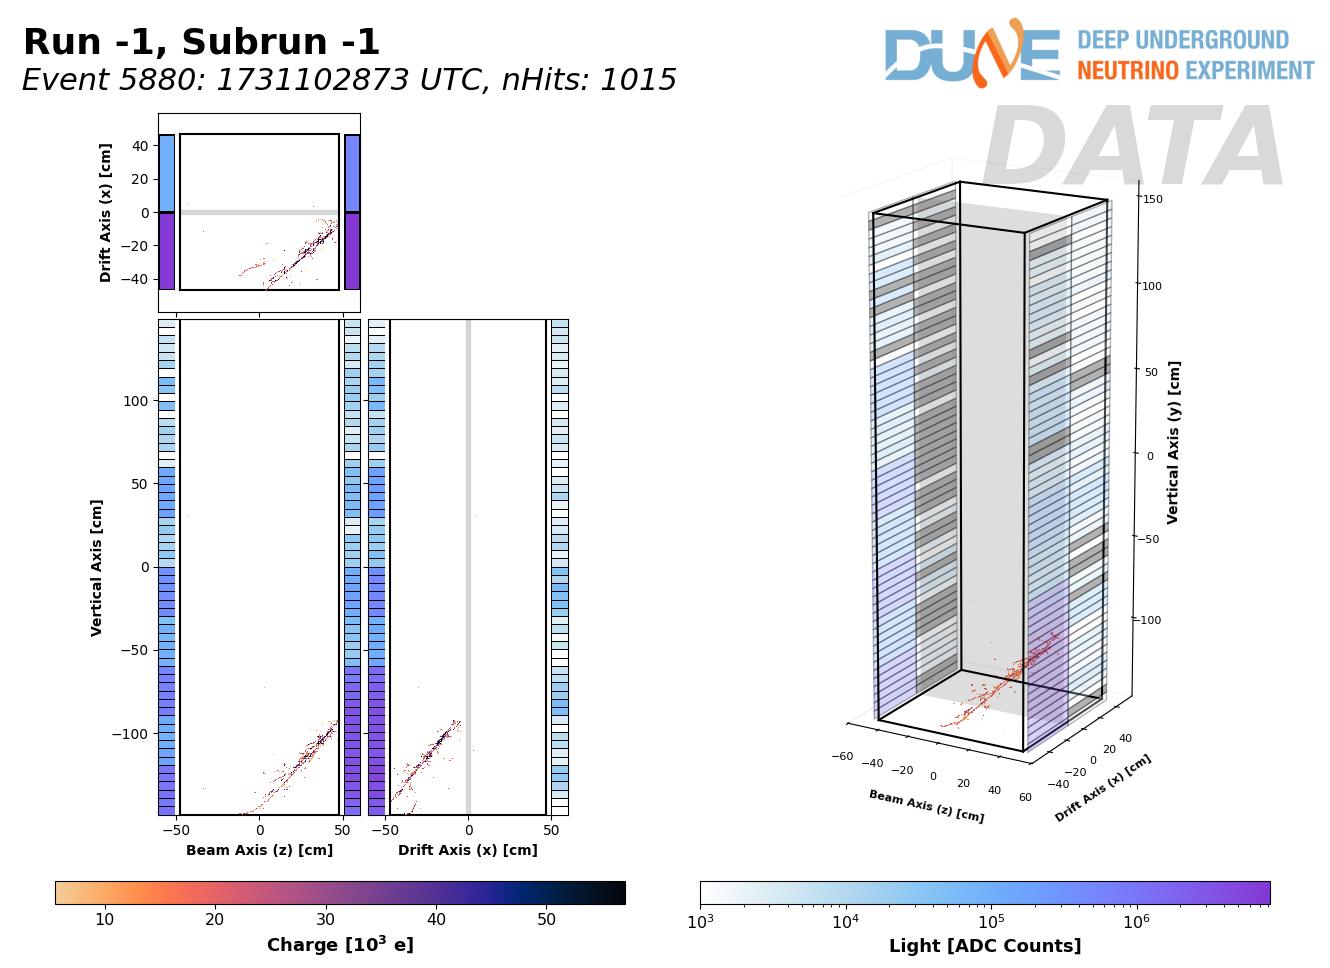

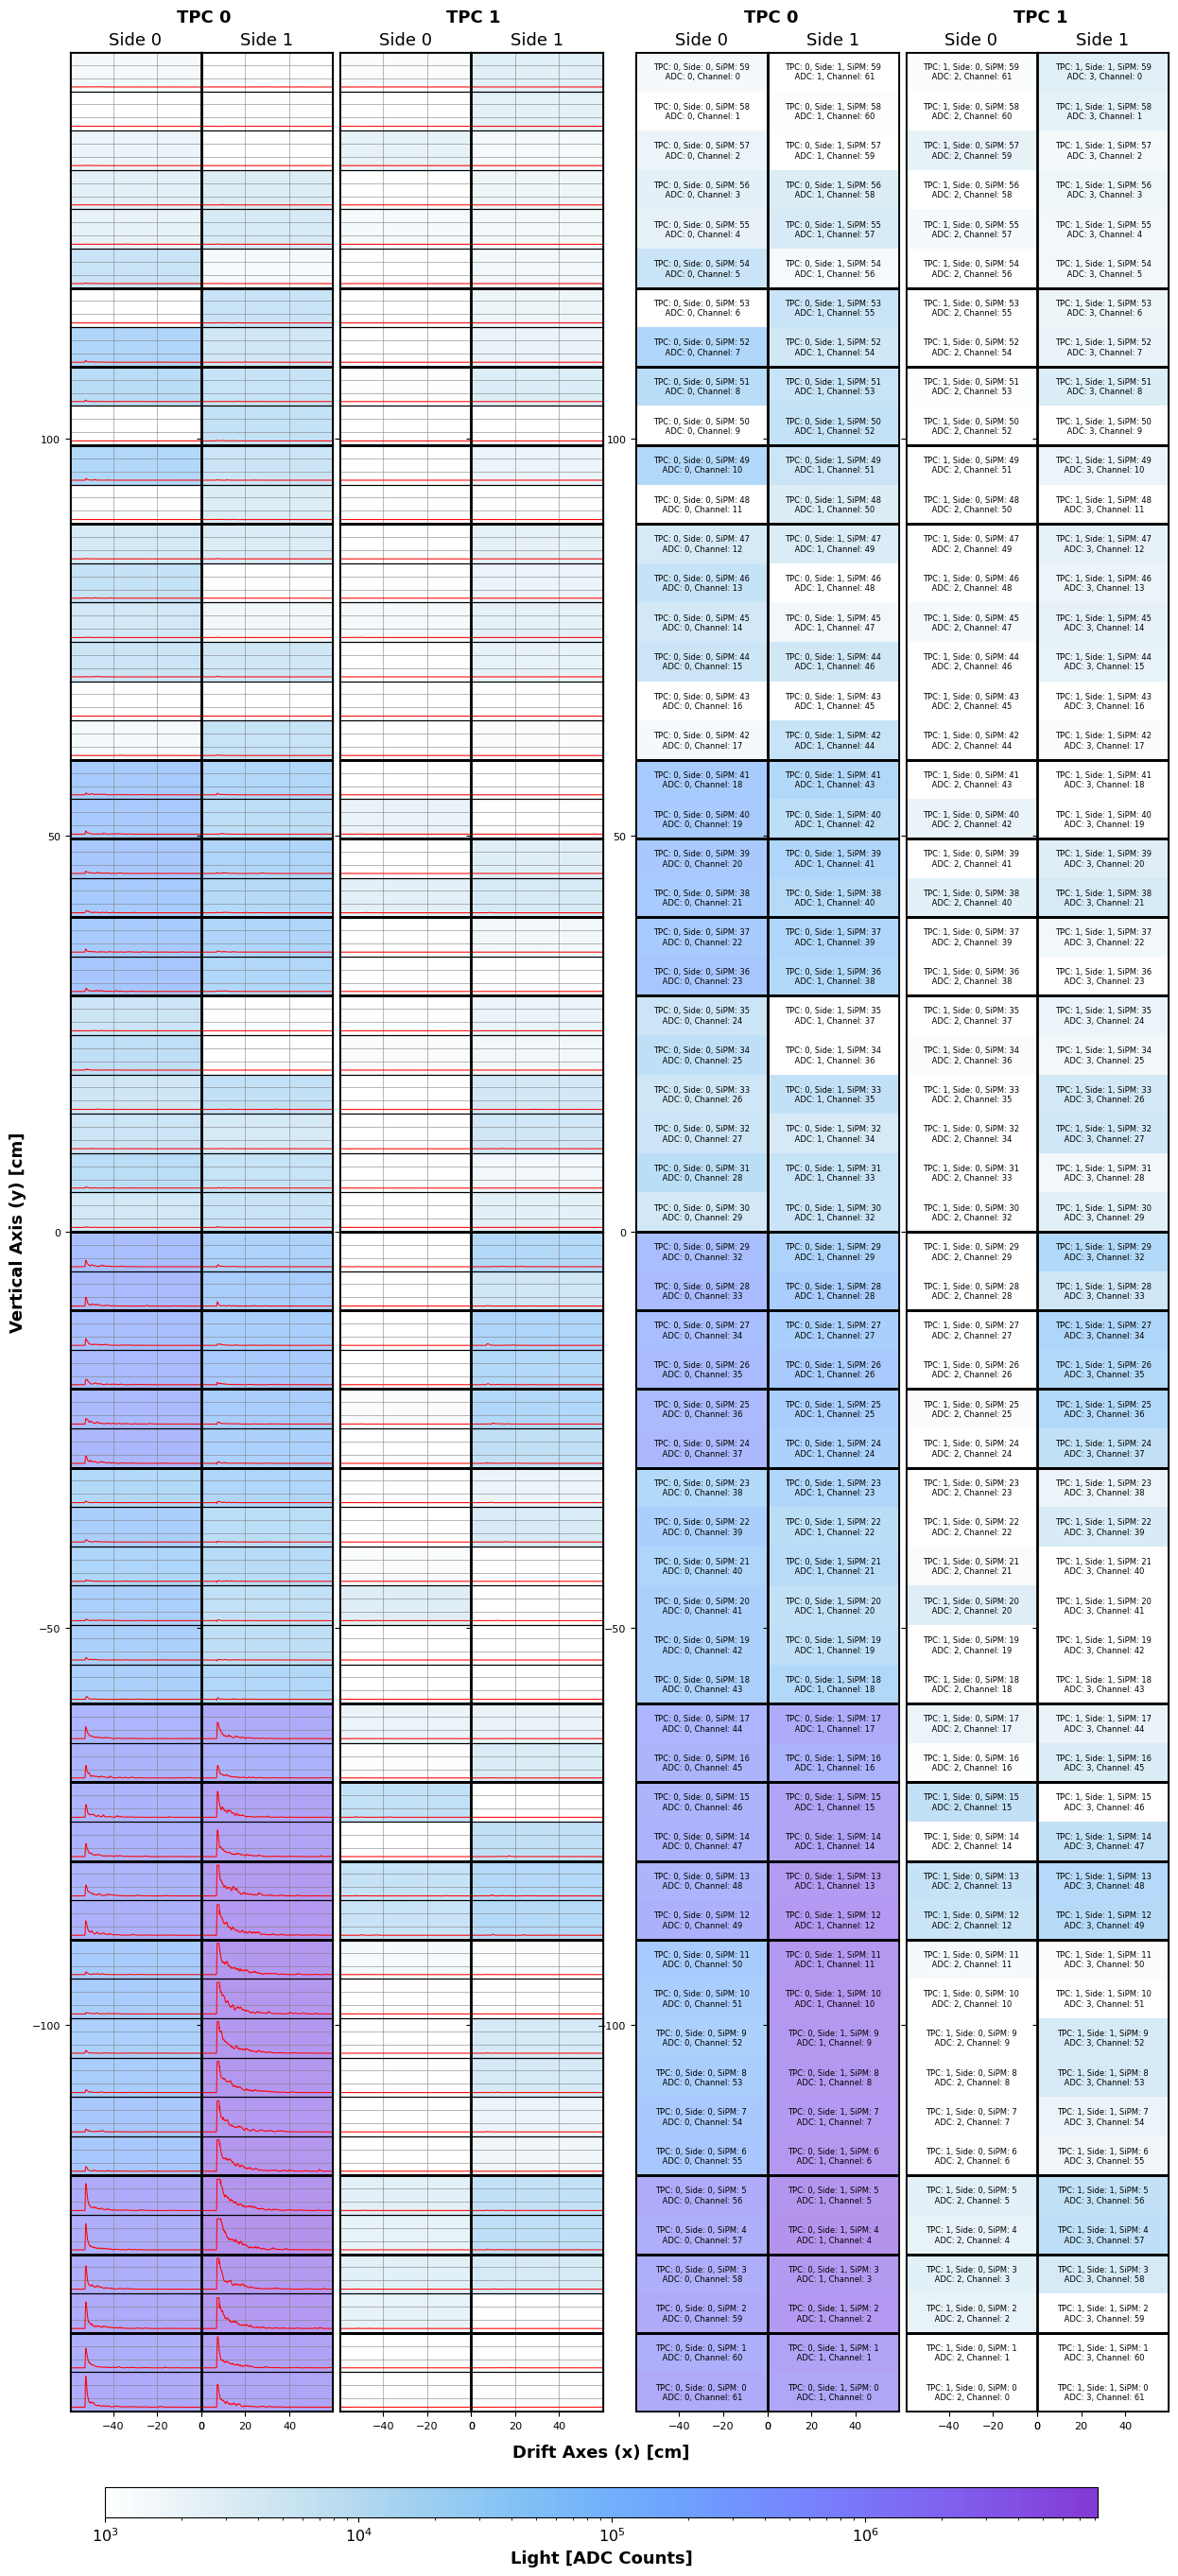

Next event (Enter: go to next event/'ev_id' + Enter: skip to event 'ev_id'/ l + Enter: list the events ID in the selection/ s + Enter: save the current plot as png/ q + Enter: exit/)?
 q


SystemExit: 

/Users/nsallin/develop/ndlar_flow.venv/lib/python3.9/site-packages/IPython/core/interactiveshell.py:3558: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


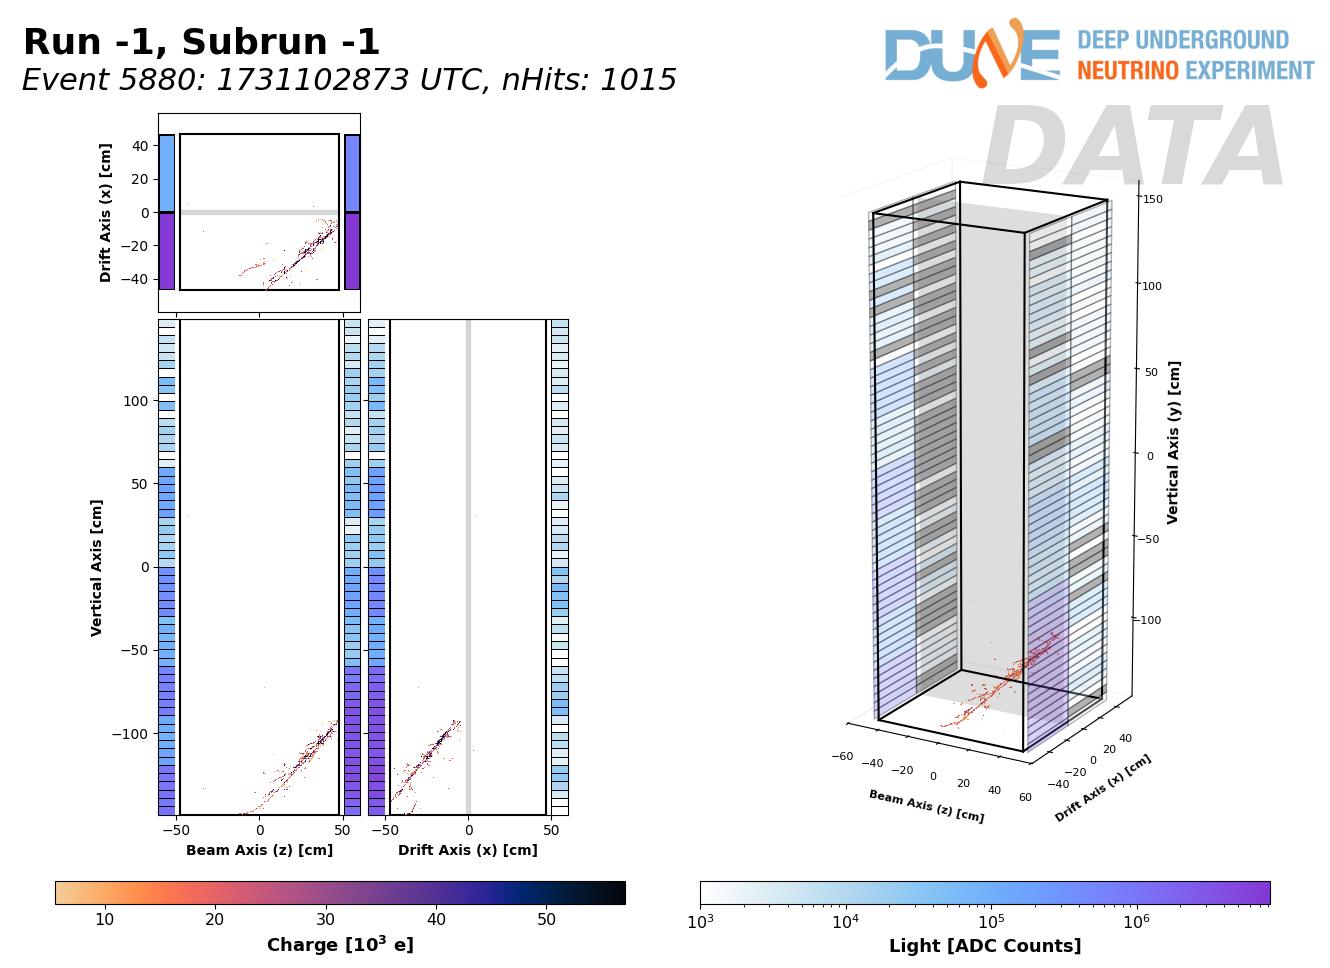

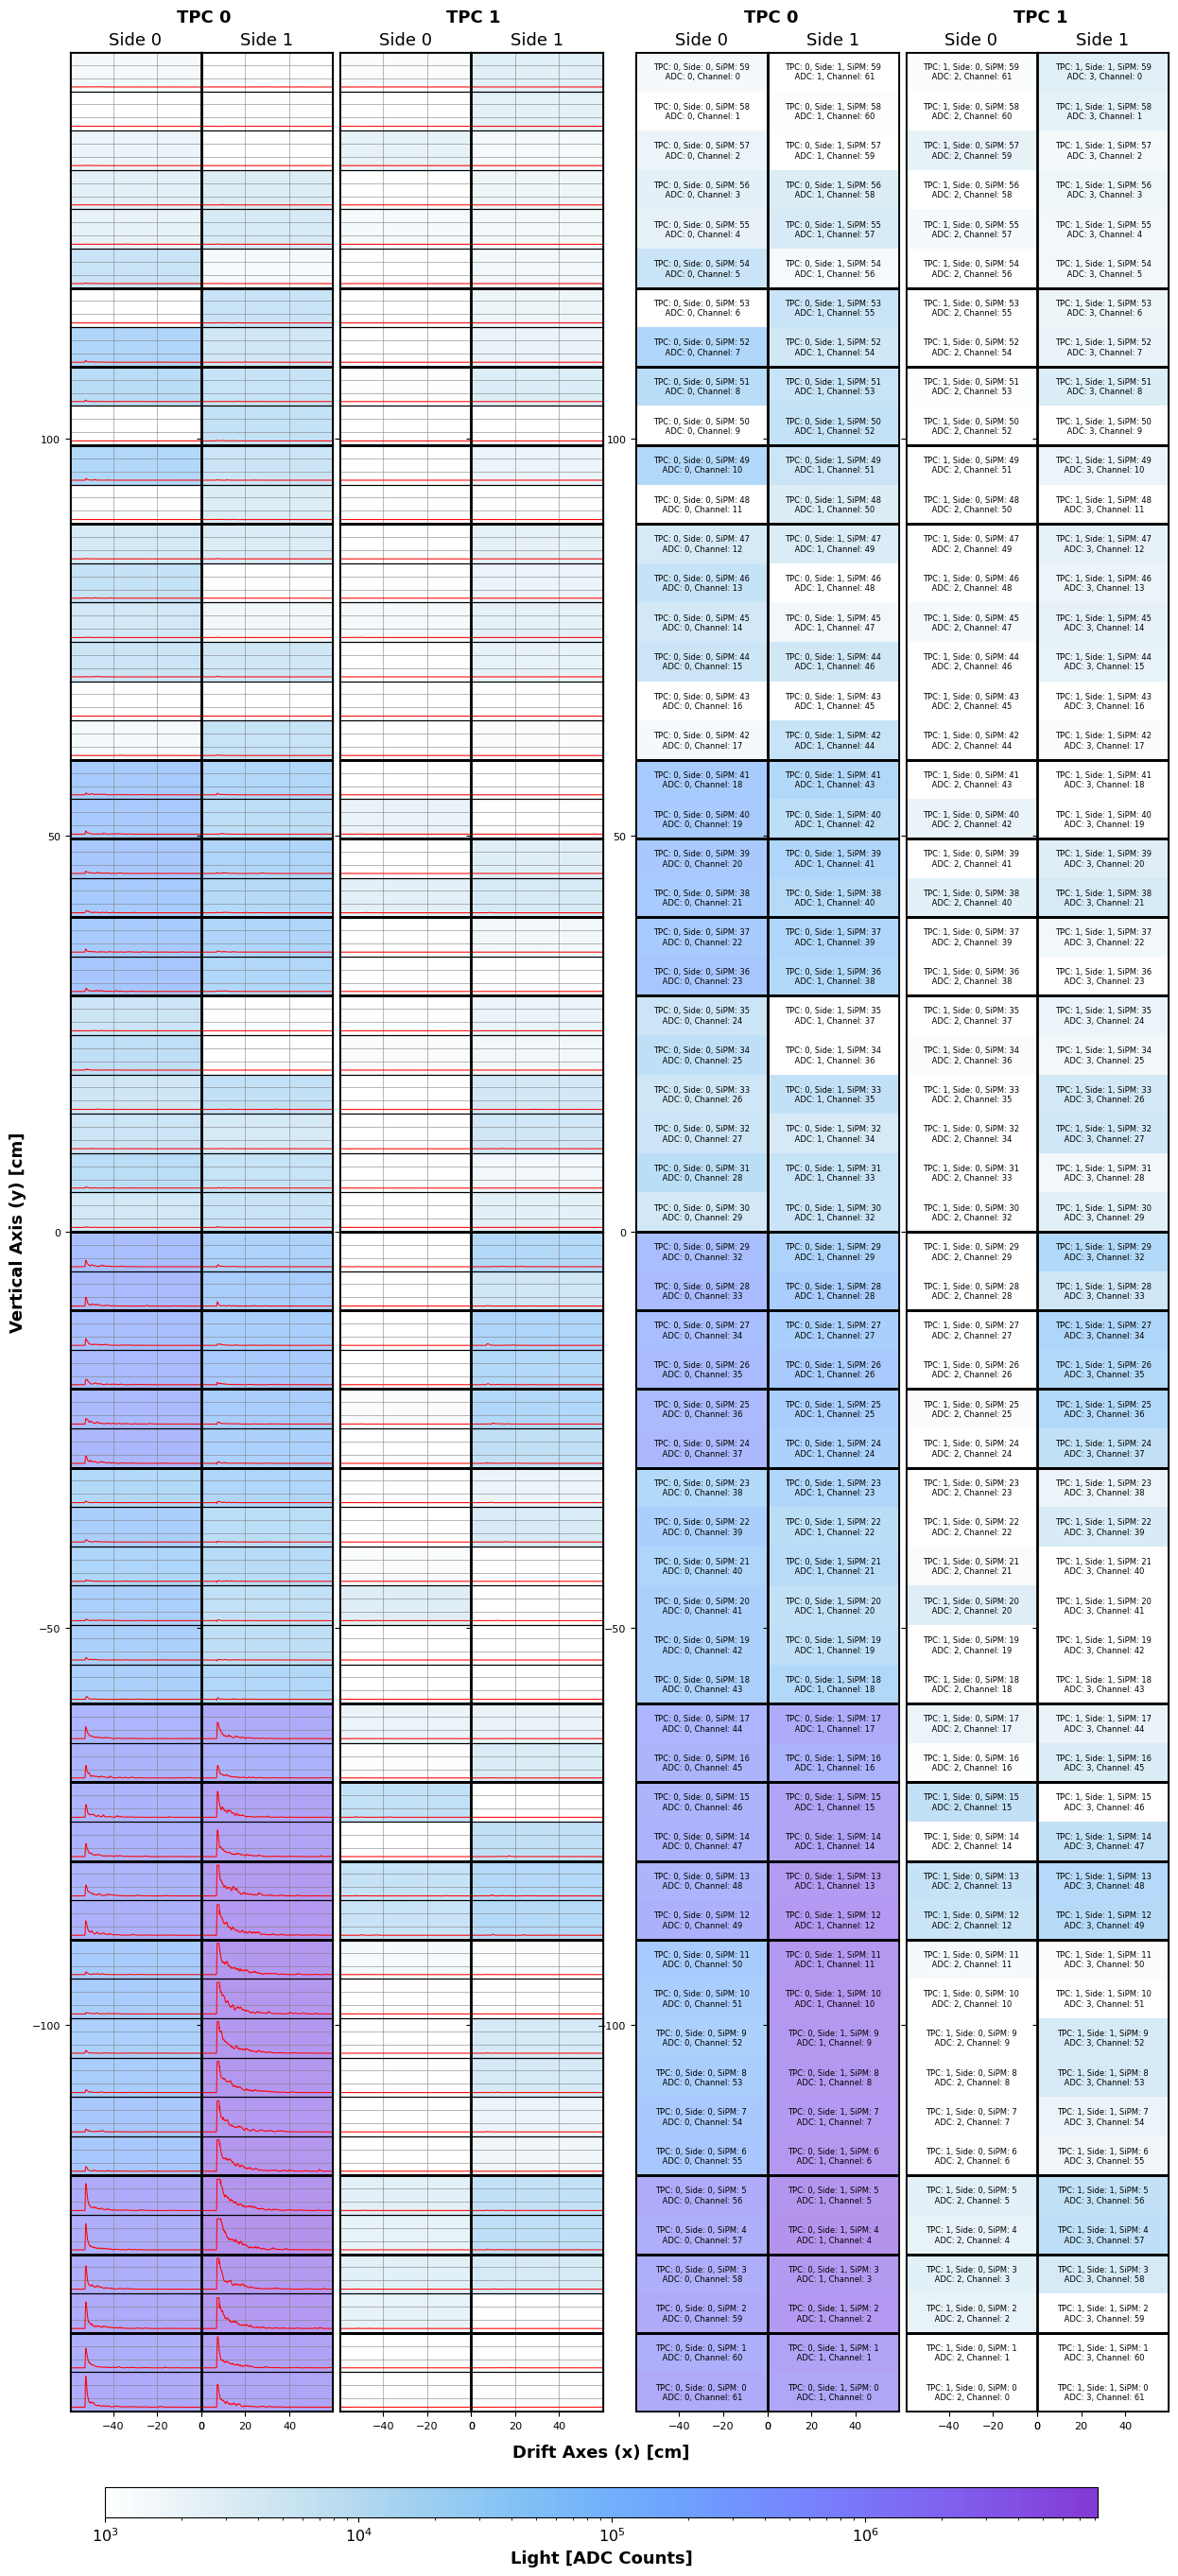

In [3]:
# evd = LArEventDisplay(filedir=d, filename=f, nhits_min=0, ntrigs=0, show_light=True, show_colorbars=True)
evd = LArEventDisplayFSD(filedir=dFSD, filename=fFSD, nhits_min=1000, ntrigs=0, show_light=True, light_event_only=True, show_fig_wfms=True, light_threshold=1000, show_colorbars=True, output_path=None)
evd.run()